In [3]:
import os
import sys

PROJECT_ROOT = r"C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)
print("scripts existe?:", os.path.exists(os.path.join(PROJECT_ROOT, "scripts")))

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos
scripts existe?: True


In [14]:
print(df_csv.columns.tolist())

['query', 'id', 'nombre', 'fecha_lanzamiento', 'rating', 'rating_count', 'generos', 'plataformas', 'cover_url', 'fecha_extraccion']


In [15]:
from scripts.database import engine

df_csv.to_sql("juegos_csv", engine, if_exists="replace", index=False)
print("Tabla juegos_csv cargada en PostgreSQL")

Tabla juegos_csv cargada en PostgreSQL


In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, probplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
n = 1000

# Variables con distintas distribuciones
release_year = np.random.randint(2015, 2026, n)                    # discreta
metascore = np.clip(np.random.normal(76, 9, n), 45, 98)           # normal
price_usd = np.clip(np.random.normal(45, 12, n), 10, 80)          # normal
hours_gameplay = np.clip(np.random.gamma(4, 10, n), 5, 120)       # gamma
marketing_score = np.clip(np.random.lognormal(2.0, 0.6, n), 2, 120)  # lognormal
social_hype = np.random.beta(2, 5, n) * 100                       # beta
discount_pct = np.random.uniform(0, 60, n)                        # uniforme
bugs_reported = np.random.poisson(6, n)                           # poisson

# rating_count depende de marketing y hype
rating_count = (
    marketing_score * 95
    + social_hype * 25
    + np.random.normal(0, 180, n)
)
rating_count = np.clip(rating_count, 50, None).round()

# rating depende de varias variables
rating = (
    8
    + 0.65 * metascore
    + 0.05 * hours_gameplay
    + 0.035 * social_hype
    + 0.0032 * rating_count
    - 0.95 * bugs_reported
    - 0.08 * price_usd
    + 0.06 * discount_pct
    + np.random.normal(0, 2.2, n)
)

rating = np.clip(rating, 50, 99)

df = pd.DataFrame({
    "release_year": release_year,
    "metascore": metascore.round(2),
    "price_usd": price_usd.round(2),
    "hours_gameplay": hours_gameplay.round(2),
    "marketing_score": marketing_score.round(2),
    "social_hype": social_hype.round(2),
    "discount_pct": discount_pct.round(2),
    "bugs_reported": bugs_reported,
    "rating_count": rating_count.astype(int),
    "rating": rating.round(2)
})

df.head()

,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
0,2021,57.66,45.80,20.71,25.16,16.06,59.39,10,2921,50.00
1,2018,66.93,51.19,50.60,12.59,21.77,24.41,6,1667,51.68
2,2025,59.16,26.25,37.40,9.18,14.66,0.66,6,1090,50.00
3,2022,72.84,38.65,15.34,9.54,9.44,10.19,3,1079,53.04
4,2019,76.17,54.53,113.23,14.37,63.59,39.15,9,2816,64.44


In [243]:
df.to_csv("../data/videojuegos_sinteticos.csv", index=False)
print("CSV guardado en ../data/videojuegos_sinteticos.csv")

CSV guardado en ../data/videojuegos_sinteticos.csv


In [244]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nResumen estadístico:")
display(df.describe())

Dimensiones: (1000, 10)

Tipos de datos:
release_year         int32
metascore          float64
price_usd          float64
hours_gameplay     float64
marketing_score    float64
social_hype        float64
discount_pct       float64
bugs_reported        int32
rating_count         int64
rating             float64
dtype: object

Resumen estadístico:


,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019.84000,76.686010,45.144000,40.256780,8.72309,28.885840,30.003330,6.088000,1553.341000,58.873950
std,3.15854,8.997272,11.717681,20.009478,5.46138,15.923036,17.645377,2.611719,685.138903,6.530026
min,2015.00000,49.930000,10.000000,5.000000,2.00000,0.650000,0.010000,0.000000,200.000000,50.000000
25%,2017.00000,70.757500,37.245000,25.880000,4.97750,16.490000,14.860000,4.000000,1082.750000,53.630000
50%,2020.00000,76.560000,45.080000,37.445000,7.37500,26.720000,29.320000,6.000000,1427.000000,58.260000
75%,2023.00000,82.477500,53.052500,51.262500,10.80500,39.490000,45.842500,8.000000,1937.250000,63.315000
max,2025.00000,98.000000,80.000000,120.000000,45.10000,81.970000,59.960000,15.000000,4824.000000,81.630000


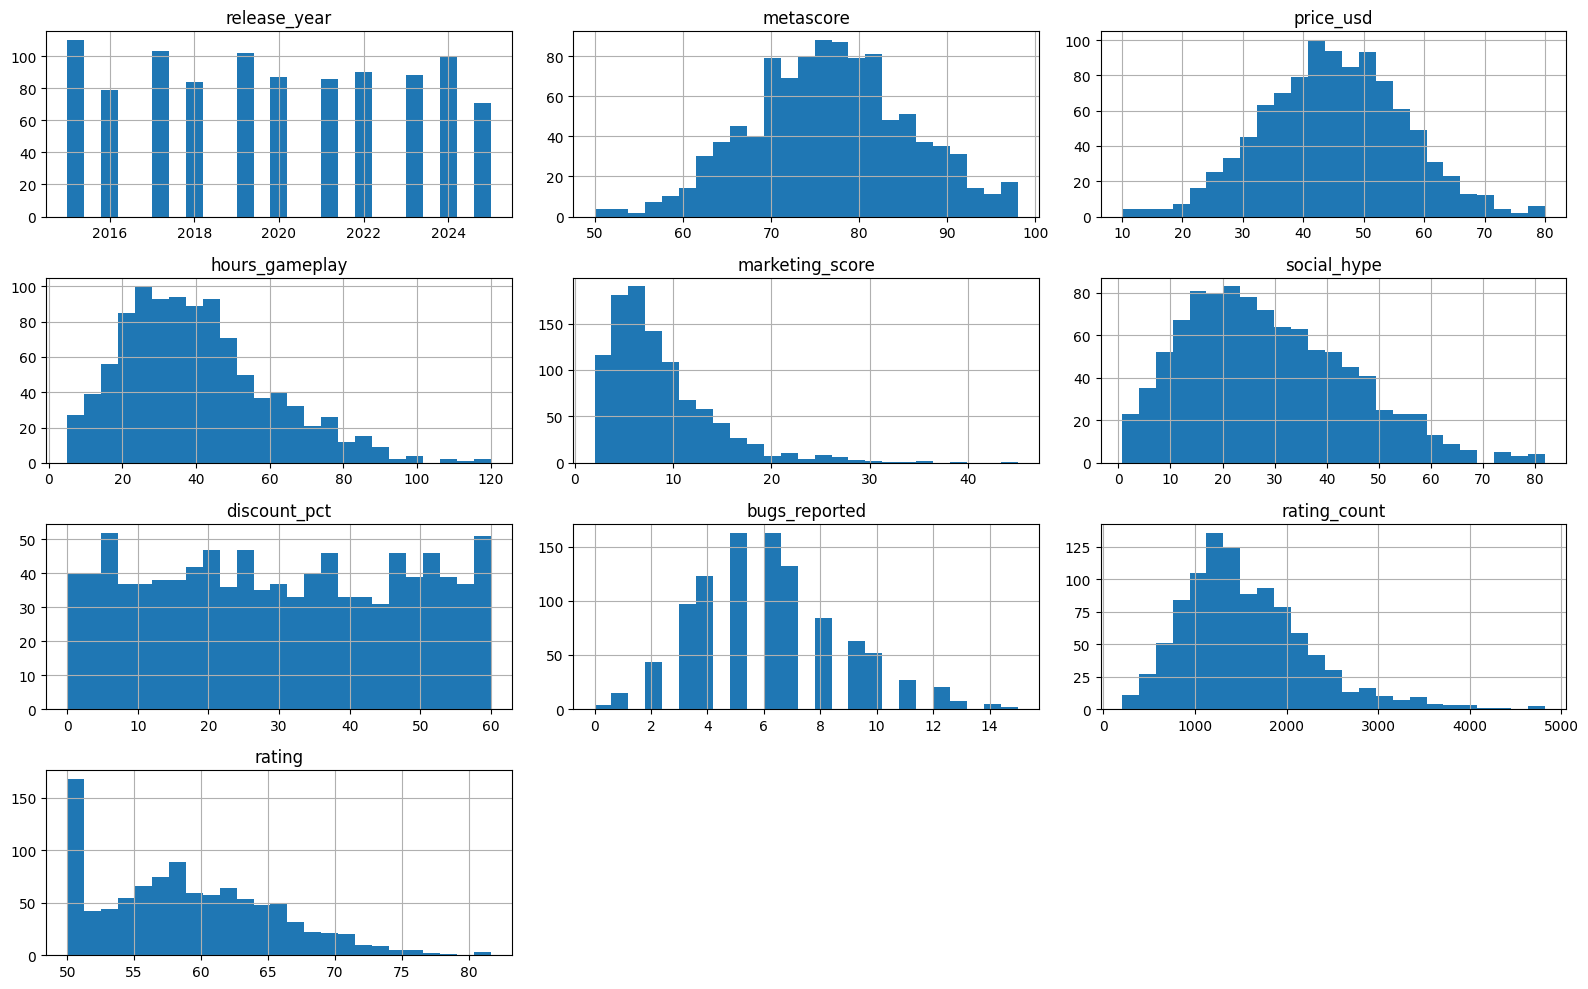

In [245]:
df.hist(figsize=(16, 10), bins=25)
plt.tight_layout()
plt.show()

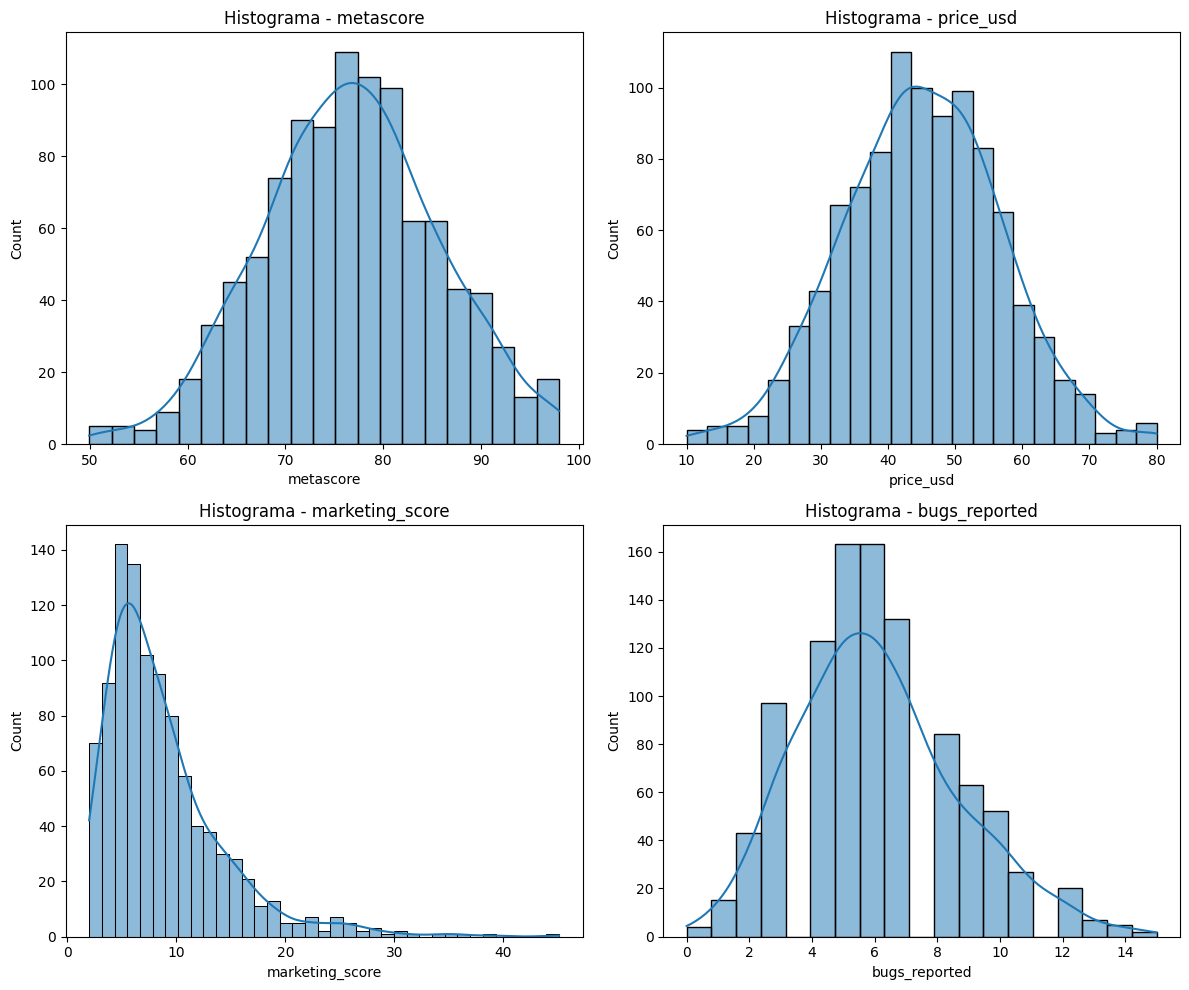

In [246]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df["metascore"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histograma - metascore")

sns.histplot(df["price_usd"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Histograma - price_usd")

sns.histplot(df["marketing_score"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Histograma - marketing_score")

sns.histplot(df["bugs_reported"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Histograma - bugs_reported")

plt.tight_layout()
plt.show()

In [247]:
variables_normalidad = ["metascore", "price_usd", "marketing_score", "rating"]

for col in variables_normalidad:
    stat, p = shapiro(df[col].sample(500, random_state=42))  # muestra de 500 para evitar problemas
    print(f"{col}: estadístico={stat:.4f}, p-valor={p:.4f}")
    if p > 0.05:
        print(" -> Se puede considerar aproximadamente normal\n")
    else:
        print(" -> No sigue una normalidad estricta\n")

metascore: estadístico=0.9965, p-valor=0.3394
 -> Se puede considerar aproximadamente normal

price_usd: estadístico=0.9977, p-valor=0.7164
 -> Se puede considerar aproximadamente normal

marketing_score: estadístico=0.8315, p-valor=0.0000
 -> No sigue una normalidad estricta

rating: estadístico=0.9573, p-valor=0.0000
 -> No sigue una normalidad estricta



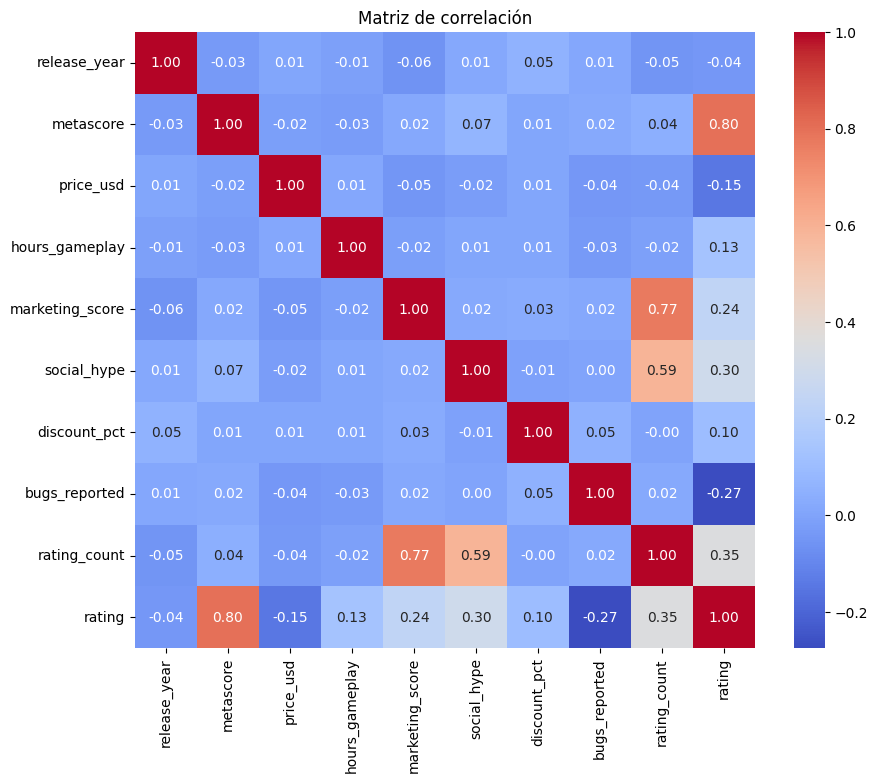

In [248]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [249]:
corr_rating = corr["rating"].sort_values(ascending=False)
print(corr_rating)


rating             1.000000
metascore          0.799517
rating_count       0.352916
social_hype        0.295010
marketing_score    0.236938
hours_gameplay     0.128668
discount_pct       0.100519
release_year      -0.041333
price_usd         -0.148672
bugs_reported     -0.274978
Name: rating, dtype: float64


In [250]:
X_simple = df[["metascore"]]
y = df["rating"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

r2_s = r2_score(y_test_s, y_pred_s)
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
mae_s = mean_absolute_error(y_test_s, y_pred_s)

print("REGRESIÓN SIMPLE")
print("R²:", round(r2_s, 4))
print("MSE:", round(mse_s, 4))
print("RMSE:", round(rmse_s, 4))
print("MAE:", round(mae_s, 4))
print("Intercepto:", round(model_simple.intercept_, 4))
print("Coeficiente metascore:", round(model_simple.coef_[0], 4))

REGRESIÓN SIMPLE
R²: 0.6604
MSE: 14.4719
RMSE: 3.8042
MAE: 2.9844
Intercepto: 14.6275
Coeficiente metascore: 0.5768


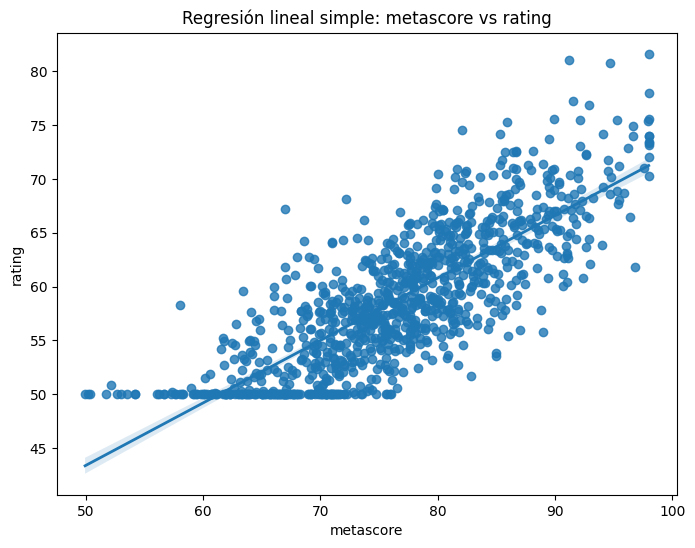

In [251]:
plt.figure(figsize=(8,6))
sns.regplot(x="metascore", y="rating", data=df, line_kws={"linewidth":2})
plt.title("Regresión lineal simple: metascore vs rating")
plt.show()

In [252]:
X_multi = df[[
    "metascore",
    "price_usd",
    "hours_gameplay",
    "social_hype",
    "discount_pct",
    "bugs_reported",
    "rating_count"
]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_m = model_multi.predict(X_test_m)

r2_m = r2_score(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)

print("REGRESIÓN MÚLTIPLE")
print("R²:", round(r2_m, 4))
print("MSE:", round(mse_m, 4))
print("RMSE:", round(rmse_m, 4))
print("MAE:", round(mae_m, 4))

REGRESIÓN MÚLTIPLE
R²: 0.8774
MSE: 5.2267
RMSE: 2.2862
MAE: 1.7705


In [253]:
coeficientes = pd.DataFrame({
    "Variable": X_multi.columns,
    "Coeficiente": model_multi.coef_
}).sort_values("Coeficiente", ascending=False)

display(coeficientes)

,Variable,Coeficiente
0,metascore,0.573085
2,hours_gameplay,0.046022
4,discount_pct,0.042786
3,social_hype,0.032566
6,rating_count,0.002694
1,price_usd,-0.078695
5,bugs_reported,-0.769435


In [254]:
comparacion = pd.DataFrame({
    "Real": y_test_m.values,
    "Predicho": y_pred_m
})

display(comparacion.head(10))

,Real,Predicho
0,60.83,61.737784
1,56.04,55.622151
2,58.61,58.766832
3,56.09,56.450959
4,50.00,45.145680
5,54.52,55.610492
6,53.93,54.967205
7,70.17,69.613093
8,50.00,48.596737
9,53.83,52.150084


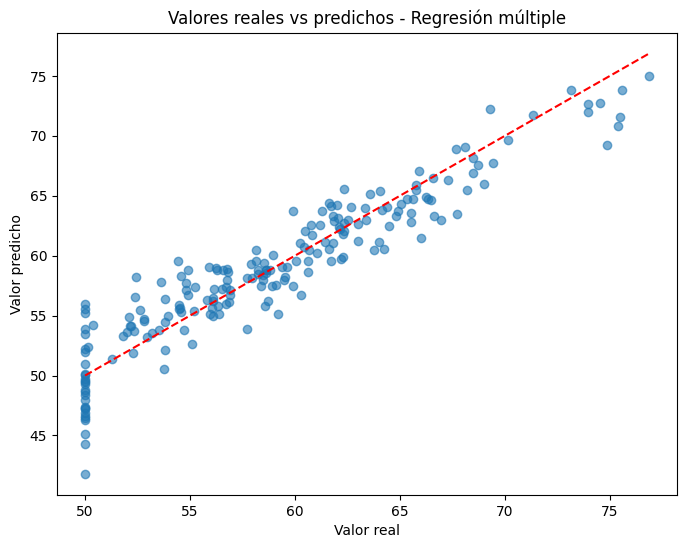

In [255]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_m, y_pred_m, alpha=0.6)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Valores reales vs predichos - Regresión múltiple")
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--')
plt.show()

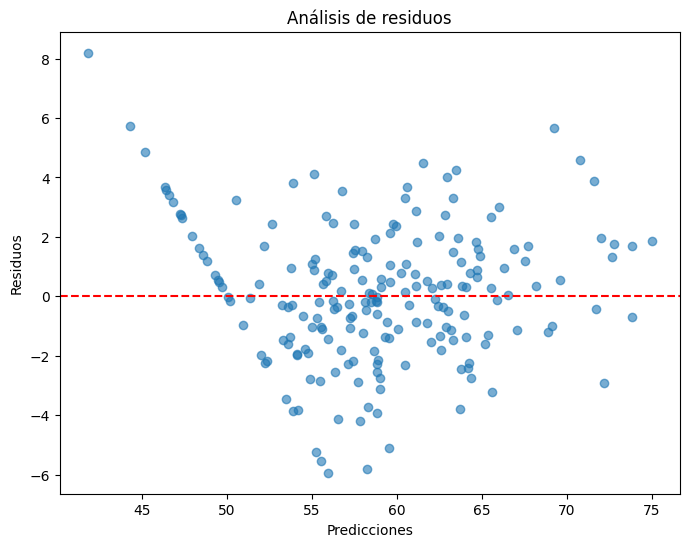

In [256]:
residuos = y_test_m - y_pred_m

plt.figure(figsize=(8,6))
plt.scatter(y_pred_m, residuos, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Análisis de residuos")
plt.show()

In [257]:
print("RESUMEN FINAL")
print(f"Cantidad de datos: {len(df)}")
print(f"Variables usadas: {list(df.columns)}")
print(f"R² simple: {r2_s:.4f}")
print(f"R² múltiple: {r2_m:.4f}")
print(f"MSE simple: {mse_s:.4f}")
print(f"MSE múltiple: {mse_m:.4f}")

RESUMEN FINAL
Cantidad de datos: 1000
Variables usadas: ['release_year', 'metascore', 'price_usd', 'hours_gameplay', 'marketing_score', 'social_hype', 'discount_pct', 'bugs_reported', 'rating_count', 'rating']
R² simple: 0.6604
R² múltiple: 0.8774
MSE simple: 14.4719
MSE múltiple: 5.2267


In [258]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree


In [259]:
X_tree = df[[
    "metascore",
    "price_usd",
    "hours_gameplay",
    "social_hype",
    "discount_pct",
    "bugs_reported",
    "rating_count"
]]

y_tree = df["rating"]

print("Variables independientes:")
print(X_tree.columns.tolist())
print("\nVariable dependiente:")
print("rating")
print("\nForma de X:", X_tree.shape)
print("Forma de y:", y_tree.shape)


Variables independientes:
['metascore', 'price_usd', 'hours_gameplay', 'social_hype', 'discount_pct', 'bugs_reported', 'rating_count']

Variable dependiente:
rating

Forma de X: (1000, 7)
Forma de y: (1000,)


In [260]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

print("Entrenamiento X:", X_train_t.shape)
print("Prueba X:", X_test_t.shape)
print("Entrenamiento y:", y_train_t.shape)
print("Prueba y:", y_test_t.shape)

Entrenamiento X: (800, 7)
Prueba X: (200, 7)
Entrenamiento y: (800,)
Prueba y: (200,)


In [261]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

In [262]:
tree_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train_t, y_train_t)

print("Árbol de regresión entrenado correctamente")

Árbol de regresión entrenado correctamente


In [263]:
y_pred_t = tree_model.predict(X_test_t)

r2_t = r2_score(y_test_t, y_pred_t)
mse_t = mean_squared_error(y_test_t, y_pred_t)
rmse_t = np.sqrt(mse_t)
mae_t = mean_absolute_error(y_test_t, y_pred_t)

print("ÁRBOL DE REGRESIÓN")
print("R²:", round(r2_t, 4))
print("MSE:", round(mse_t, 4))
print("RMSE:", round(rmse_t, 4))
print("MAE:", round(mae_t, 4))

ÁRBOL DE REGRESIÓN
R²: 0.652
MSE: 14.8296
RMSE: 3.8509
MAE: 3.0311


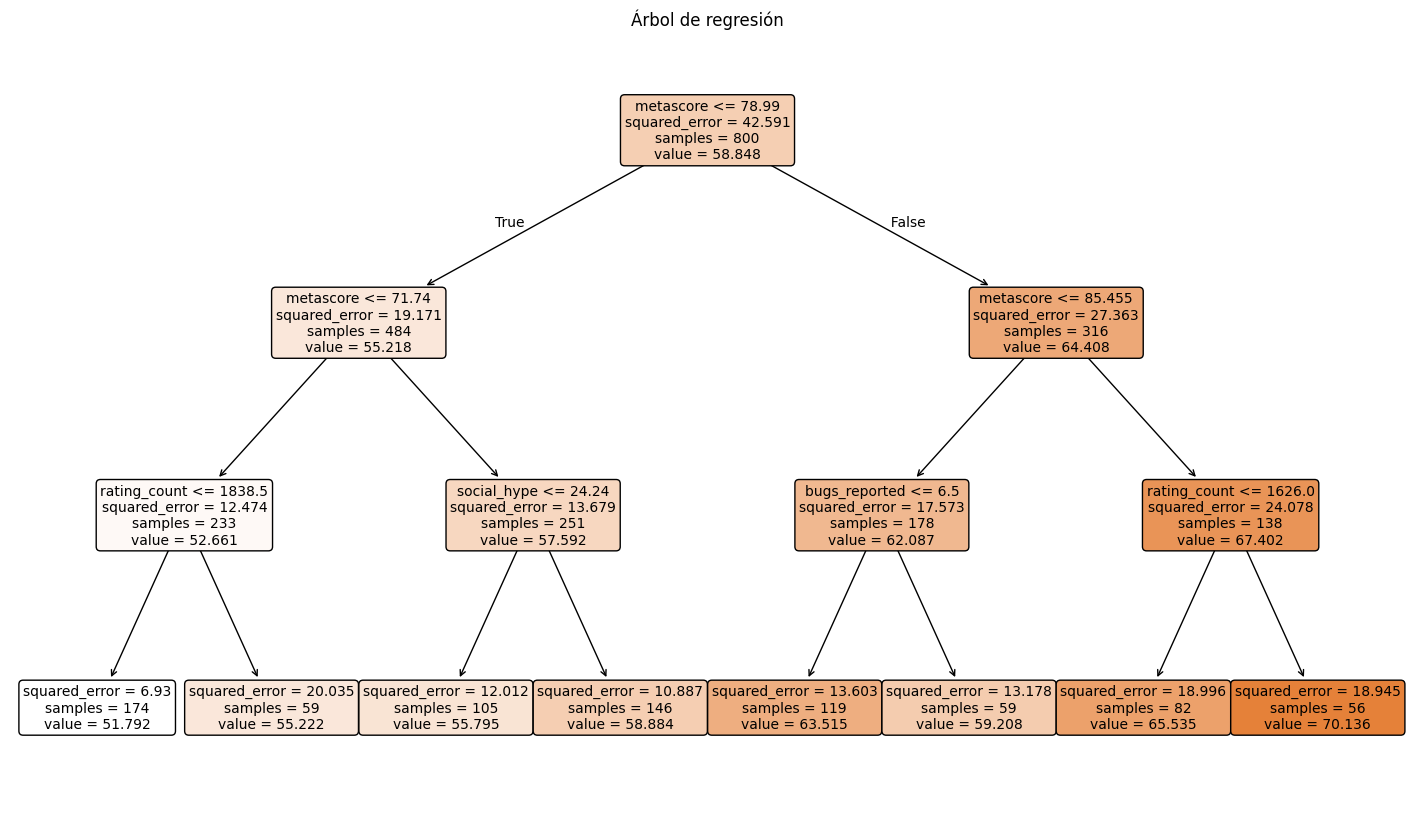

In [264]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_model,
    feature_names=X_tree.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de regresión")
plt.show()

In [265]:
reglas = export_text(tree_model, feature_names=list(X_tree.columns))
print("REGLAS DE DECISIÓN - ÁRBOL DE REGRESIÓN")
print(reglas)

REGLAS DE DECISIÓN - ÁRBOL DE REGRESIÓN
|--- metascore <= 78.99
|   |--- metascore <= 71.74
|   |   |--- rating_count <= 1838.50
|   |   |   |--- value: [51.79]
|   |   |--- rating_count >  1838.50
|   |   |   |--- value: [55.22]
|   |--- metascore >  71.74
|   |   |--- social_hype <= 24.24
|   |   |   |--- value: [55.80]
|   |   |--- social_hype >  24.24
|   |   |   |--- value: [58.88]
|--- metascore >  78.99
|   |--- metascore <= 85.45
|   |   |--- bugs_reported <= 6.50
|   |   |   |--- value: [63.51]
|   |   |--- bugs_reported >  6.50
|   |   |   |--- value: [59.21]
|   |--- metascore >  85.45
|   |   |--- rating_count <= 1626.00
|   |   |   |--- value: [65.54]
|   |   |--- rating_count >  1626.00
|   |   |   |--- value: [70.14]

